# Regression & Supernova II

Let's explore data driven (non-parametric) and parametric fit for non linear dataset.

In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

(35.0, 50.0)

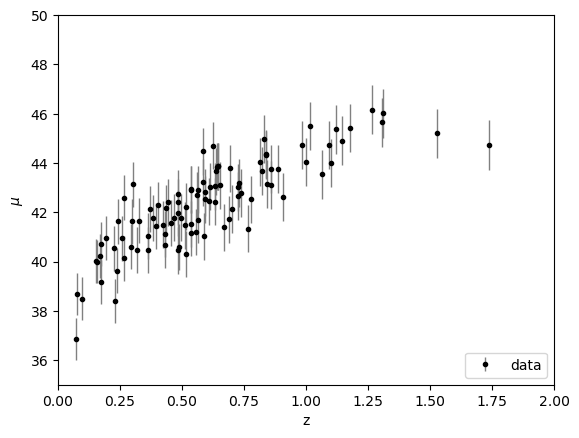

In [2]:
from astroML.datasets import generate_mu_z
z, mu, dmu = generate_mu_z(100, random_state=1234)

plt.errorbar(z, mu, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

(35.0, 50.0)

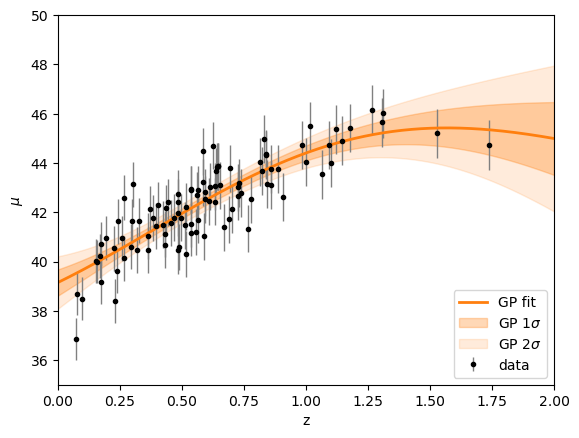

In [3]:
from sklearn.gaussian_process import GaussianProcessRegressor, kernels

kernel = kernels.ConstantKernel(1, constant_value_bounds=(1e-3, 1e3)) * kernels.RBF(length_scale=10, length_scale_bounds=(1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, alpha=dmu**2, normalize_y=True)
gp.fit(z[:, np.newaxis], mu)
z_fit = np.linspace(0, 2, 1000)[:, np.newaxis]
mu_fit, dmu_fit = gp.predict(z_fit, return_std=True)

plt.errorbar(z, mu, dmu, fmt='.k', ecolor='gray', lw=1, label='data')
plt.plot(z_fit, mu_fit, color='C1', lw=2, label='GP fit')
plt.fill_between(z_fit.ravel(), mu_fit - dmu_fit, mu_fit + dmu_fit, color='C1', alpha=0.3, label='GP $1\sigma$')
plt.fill_between(z_fit.ravel(), mu_fit - 2*dmu_fit, mu_fit + 2*dmu_fit, color='C1', alpha=0.15, label='GP $2\sigma$')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0, 2)
plt.ylim(35, 50)

### Lambda CDM Model

We want to study this parametrically (i.e. fitting a given physical model) such that:

$$\mu = 5 \log \left( \frac{c/H_0} {10 {\rm pc}}(1+z)\int_0^z \frac{dz'}{\sqrt{\Omega_m (1+z)^3+\Omega_\Lambda}} \right) $$

In [4]:
import emcee
from dynesty import NestedSampler
from dynesty import plotting as dyplot
from dynesty import utils as dyfunc
import corner

In [5]:
# Define the model
def LambdaCDM(z, H0, omegaM):
    c = 299792.458
    omegaL = 1 - omegaM

    def integrand(x):
        return 1.0 / np.sqrt(omegaM * (1 + x)**3 + omegaL)

    z_arr = np.atleast_1d(z)
    integral = np.array([scipy.integrate.quad(integrand, 0, zi)[0] for zi in z_arr])
    d_l_mpc = (100000 * c / H0) * (1 + z_arr) * integral
    mu = 5 * np.log10(d_l_mpc)

    return mu.item() if np.isscalar(z) else mu

# Define the logLikelihood
def logLikelihood(theta, z, mu, error):
    H0, omegaM = theta
    model = LambdaCDM(z, H0, omegaM)
    logL = -0.5 * np.sum(((mu - model) / error) ** 2)
    return logL

# Define the logPrior
def logPrior(theta):
    H0, omegaM = theta
    if 0 < H0 < 100 and 0 < omegaM < 1:
        return 0.0  
    return -np.inf  

# Define the prior transformation
def priorTransform(u):
    H0 = 100 * u[0]  # Map u[0] from [0, 1] to [0, 100]
    omegaM = u[1]  # Map u[1] from [0, 1] to [0, 1]
    return H0, omegaM

# Define logPosterior
def logPosterior(theta, z, mu, error):
    lp = logPrior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + logLikelihood(theta, z, mu, error)

In [6]:
LambdaCDM(0.2, 70, 0.3)

39.95628079616643

I've also tried Metropolis-Hastings MCMC, but it takes 20 minutes to run. Then prefer using NastedSampling.

In [ ]:
ndim = 2
nwalkers = 100
sampler = emcee.EnsembleSampler(nwalkers, ndim, logPosterior, args=(z, mu, dmu))
initial = np.array([70, 0.3]) + 1e-4 * np.random.randn(nwalkers, ndim)

sampler.run_mcmc(initial, 5000, progress=True)

In [ ]:
samples = sampler.get_chain(discard=1000, thin=max(1, int(np.max(sampler.get_autocorr_time())) * 10), flat=True)

In [ ]:
labels = ["H0", "Omega_M"]

fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(sampler.get_chain()[:, :, i], "k", alpha=0.3)
    ax.set_ylabel(labels[i])
axes[-1].set_xlabel("Step number")
plt.tight_layout()
plt.show()

In [ ]:
corner.corner(samples,
            labels=labels, 
            quantiles=[0.16, 0.5, 0.84],  
            show_titles=True,
            title_kwargs={"fontsize": 12},
            levels=[0.68, 0.95]
)
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(z_fit.ravel(), LambdaCDM(z_fit.ravel(), *samples.mean(axis=0)), color='C1', lw=2, label='MCMC fit')
plt.errorbar(z, mu, dmu, fmt='.k', ecolor='gray', lw=1, label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.show()

In [7]:
ndim = 2

sampler = NestedSampler(logLikelihood, priorTransform, ndim, nlive=2000, logl_args=(z, mu, dmu))
sampler.run_nested()

samples = sampler.results['samples']
weights = np.exp(sampler.results['logwt'] - sampler.results['logz'][-1])

samples = dyfunc.resample_equal(samples, weights)

5211it [01:08, 75.60it/s, +2000 | bound: 0 | nc: 1 | ncall: 29781 | eff(%): 25.957 | loglstar:   -inf < -46.386 <    inf | logz: -49.247 +/-    nan | dlogz:  0.001 >  2.009]


(<Figure size 1600x1600 with 4 Axes>,
 array([<Axes: xlabel='$-\\ln X$', ylabel='Live Points'>,
        <Axes: xlabel='$-\\ln X$', ylabel='Likelihood\n(normalized)'>,
        <Axes: xlabel='$-\\ln X$', ylabel='Importance\nWeight PDF'>,
        <Axes: xlabel='$-\\ln X$', ylabel='Evidence'>], dtype=object))

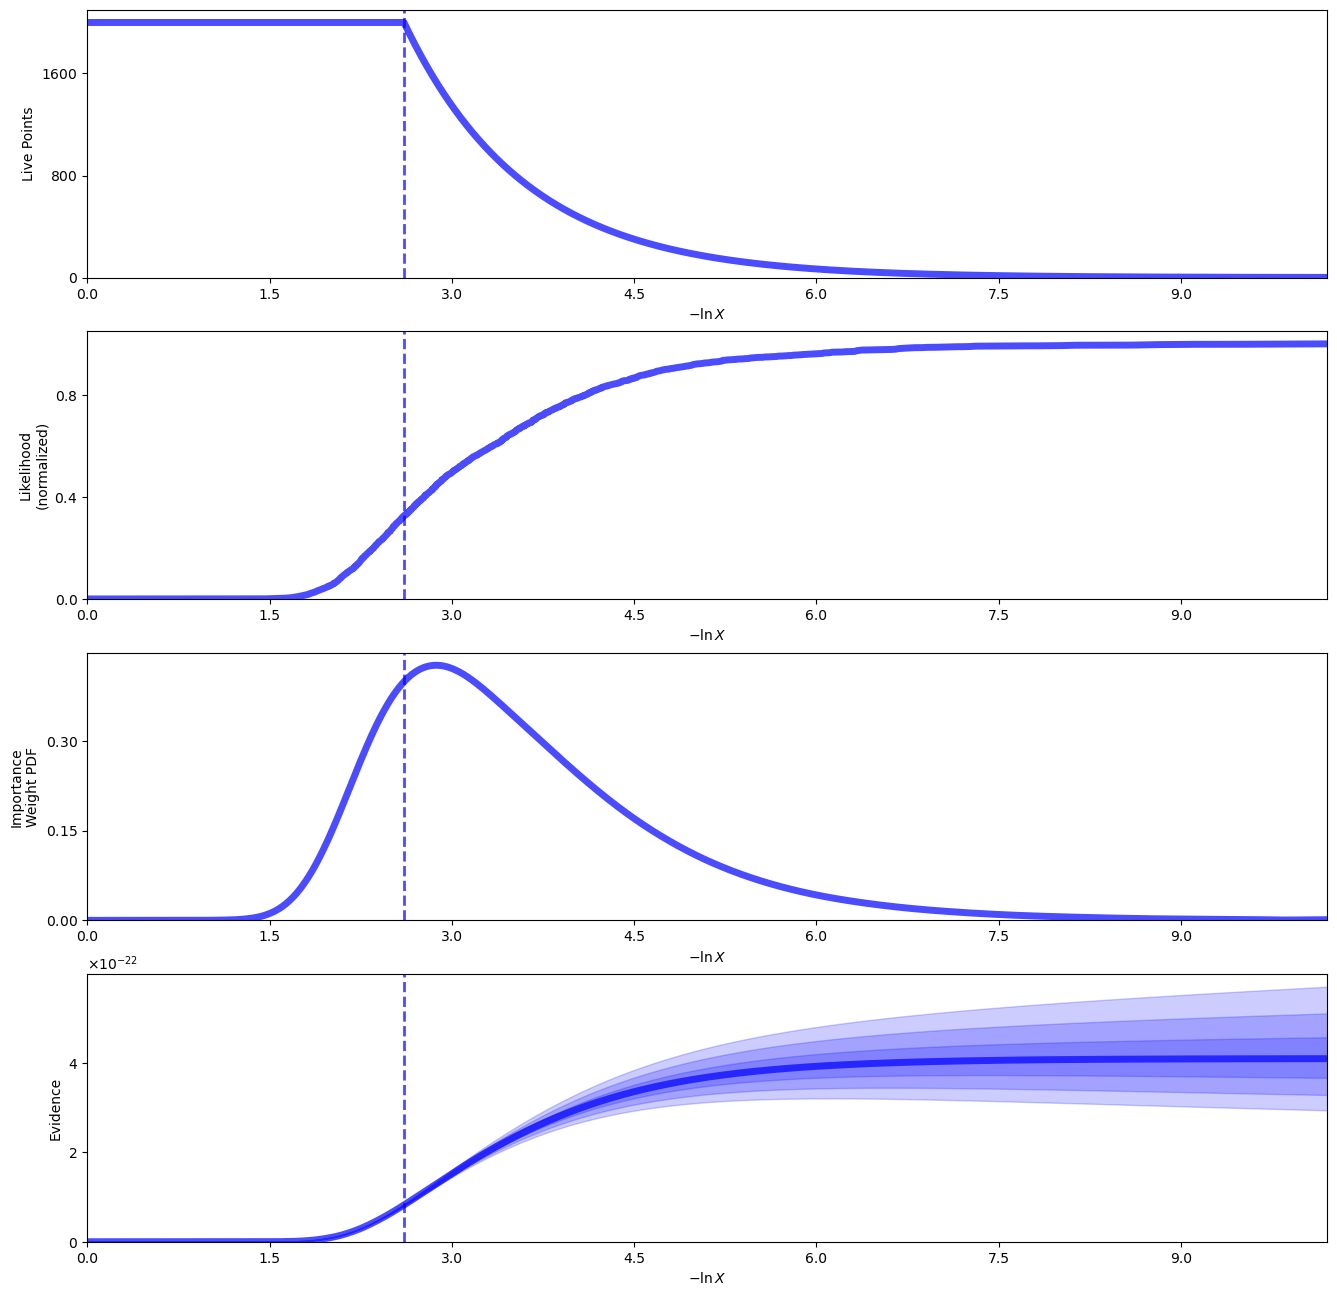

In [8]:
dyplot.runplot(sampler.results)

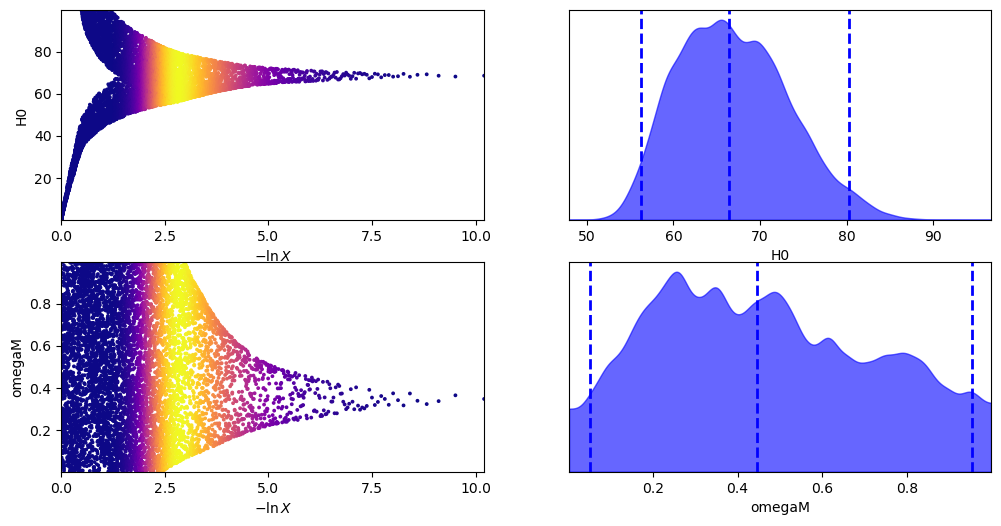

In [9]:
labels = ["H0", "omegaM"]

fig, axes = dyplot.traceplot(sampler.results, labels=labels)
plt.show()

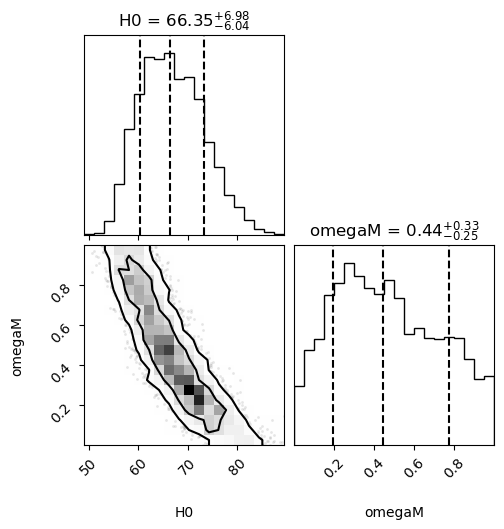

In [10]:
corner.corner(
    samples,
    labels=labels,
    quantiles=[0.16, 0.5, 0.84],  
    show_titles=True,
    title_kwargs={"fontsize": 12},
    levels=[0.68, 0.95],
)
plt.show()

/var/folders/y3/hmkzfhj13553n22ygq7syz5r0000gn/T/ipykernel_11358/948458971.py:12: RuntimeWarning: divide by zero encountered in log10
  mu = 5 * np.log10(d_l_mpc)


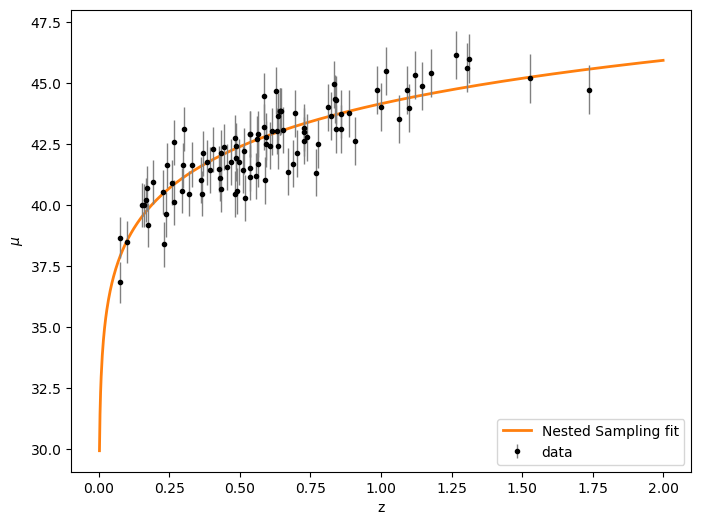

In [11]:
plt.figure(figsize=(8, 6))
plt.plot(z_fit.ravel(), LambdaCDM(z_fit.ravel(), *sampler.results['samples'].mean(axis=0)), color='C1', lw=2, label='Nested Sampling fit')
plt.errorbar(z, mu, dmu, fmt='.k', ecolor='gray', lw=1, label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.show()

We want to explore the no dark matter hypotesis ($\Omega_m = 1$). We run a new nested sempler for this different model and compute Bayes factor.

In [12]:
def LambdaCDM_ndr (z, H0):
    return LambdaCDM(z, H0, 1)

def logLikelihood_ndr(theta, z, mu, error):
    H0 = theta[0]
    model = LambdaCDM_ndr(z, H0)
    logL = -0.5 * np.sum(((mu - model) / error) ** 2)
    return logL

def priorTransform_ndr(u):
    return u * 100  

In [13]:
ndim = 1

sampler_ndm = NestedSampler(logLikelihood_ndr, priorTransform_ndr, ndim, nlive=2000, logl_args=(z, mu, dmu))
sampler_ndm.run_nested()

5311it [01:05, 80.54it/s, +2000 | bound: 0 | nc: 1 | ncall: 30760 | eff(%): 25.421 | loglstar:   -inf < -47.102 <    inf | logz: -49.852 +/-    nan | dlogz:  0.001 >  2.009]


In [14]:
evidence = sampler.results['logz'][-1]
evidence_ndm = sampler_ndm.results['logz'][-1]

print(f"LogEvidence for LambdaCDM: {evidence:.2f}")
print(f"LogEvidence for LambdaCDM with Omega_M=1: {evidence_ndm:.2f}")
print(f"LogBayes factor (LambdaCDM / LambdaCDM with Omega_M=1): {evidence - evidence_ndm:.2f}")

LogEvidence for LambdaCDM: -49.25
LogEvidence for LambdaCDM with Omega_M=1: -49.85
LogBayes factor (LambdaCDM / LambdaCDM with Omega_M=1): 0.60


There is not enought evidence to conclude from the given data the presence of dark matter.

### Cloning data set

What can we do with ten times the mesurment we have now? Using prediction from GP regression, we can predict also errors.

In [15]:
from sklearn.neighbors import KernelDensity

kde = KernelDensity(kernel='tophat', bandwidth=0.1).fit(z[:, np.newaxis])

In [16]:
print(len(z))

100


In [17]:
N = 10*len(z) 

z_clone = kde.sample(N, random_state=1234)
z_clone = np.clip(z_clone, 0, 2)
z_clone = z_clone.ravel()  

mu_clone, std_mu_clone = gp.predict(z_clone[:, np.newaxis], return_std=True)

/var/folders/y3/hmkzfhj13553n22ygq7syz5r0000gn/T/ipykernel_11358/1745323150.py:9: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  plt.errorbar(z_clone, mu_clone, std_mu_clone, color='blue', fmt='.k', ecolor='blue', lw=1, label='Cloned data')


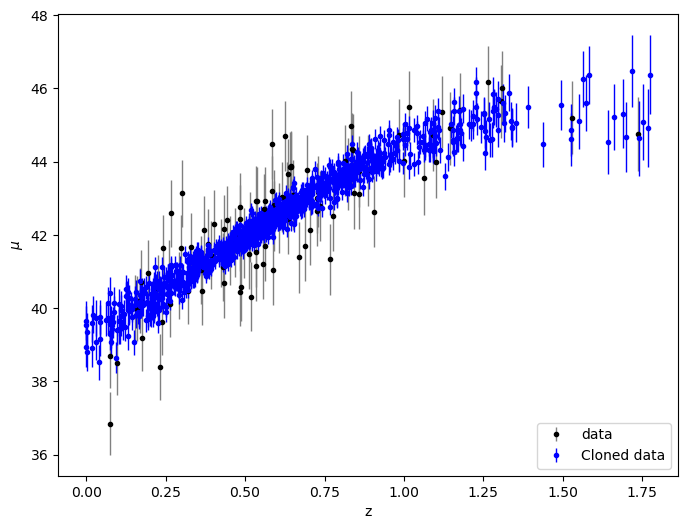

In [ ]:
mu_clone, std_mu_clone = gp.predict(z_clone[:, np.newaxis], return_std=True)
mu_clone = mu_clone + np.random.normal(0, std_mu_clone, size=mu_clone.shape)

plt.figure(figsize=(8, 6))
plt.errorbar(z, mu, dmu, fmt='.k', ecolor='gray', lw=1, label='data')
plt.errorbar(z_clone, mu_clone, std_mu_clone, color='blue', fmt='.k', ecolor='blue', lw=1, label='Cloned data')
plt.xlabel('z')
plt.ylabel('$\mu$')
plt.legend(loc='lower right')
plt.show()

In [25]:
from sklearn.model_selection import learning_curve, GridSearchCV

In [27]:
grid = GridSearchCV(
    estimator=GaussianProcessRegressor(kernel=kernel, normalize_y=True),
    param_grid={
        'alpha': [1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7]
    },
    cv=5,
    scoring=None,
    n_jobs=-1
)

grid.fit(z_clone[:, np.newaxis], mu_clone)
best_alpha = grid.best_params_['alpha']
print(f"Best alpha: {best_alpha}")

/opt/anaconda3/envs/astrostats/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/envs/astrostats/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/envs/astrostats/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/envs/astrostats/l

Best alpha: 0.01


/opt/anaconda3/envs/astrostats/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


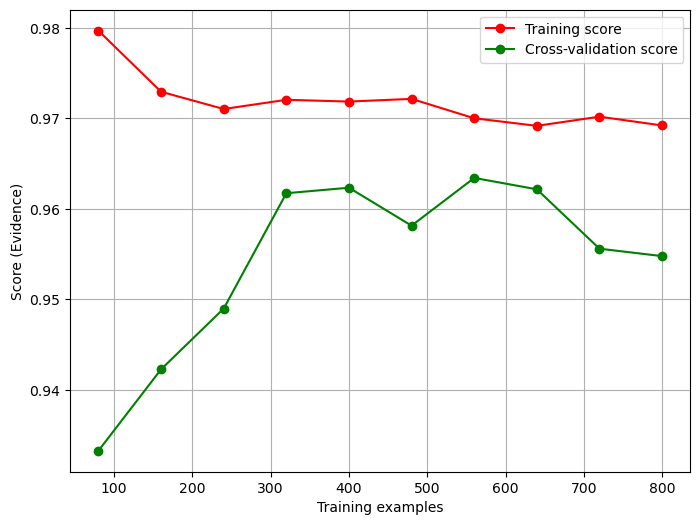

In [33]:
gp_alpha = GaussianProcessRegressor(kernel=kernel, alpha=best_alpha, normalize_y=True)

train_sizes, train_scores, test_scores = learning_curve(gp_alpha, z_clone[:, np.newaxis], mu_clone, cv=5, train_sizes = np.linspace(0.1, 1, 10), scoring=None, n_jobs=-1) 

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color='r', label='Training score')
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', color='g', label='Cross-validation score')
plt.xlabel('Training examples')
plt.ylabel('Score (Evidence)')
plt.legend(loc='best')
plt.grid()

_Last question to answare:_ can we with more data get evidence of the necessity of Dark Matter?